# Employee Attrition Prediction using Machine Learning
**Intern:** Vaishnav  
**Internship Project — Week 2**  
**Dataset:** IBM HR Analytics Employee Attrition (`HR_Attrition.csv`, 1470 rows, 35 columns)

Goal: figure out which employees are likely to leave, why they leave, and what HR can actually do about it.


**🎯 Problem Statement**

 Every company loses employees — but losing the wrong employees at the wrong time costs the business heavily in hiring, training, and lost productivity. HR departments at large companies spend crores every year trying to figure out who is likely to leave and why — before it happens. This is called Employee Attrition Prediction, and it is one of the most widely used real-world applications of data science in the corporate world today.
Your task is to build a Machine Learning system that predicts whether an employee is likely to leave the company based on factors like job satisfaction, salary, work-life balance, years at the company, and performance ratings.

You will clean and prepare HR data, handle categorical features, train and compare classification models, analyze what actually drives employees to leave, and deliver insights that an HR team could act on immediately.






**Task 1 — Data Loading & Exploration**

In [1]:
# first of all we will import all the important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# we will load dataset using pandas
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head(10) #shows the first 10 rows

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [5]:
print("Rows,Columns:",df.shape)

Rows,Columns: (1470, 35)


In [6]:
# Target column is 'Attrition' -> Yes means the employee left, No means they stayed
counts = df['Attrition'].value_counts()
attrition_rate = counts['Yes'] / counts.sum() * 100
print(counts)
print(f"\nAttrition rate: {attrition_rate:.2f}%")

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate: 16.12%


In [7]:
# Identify how many columns are numeric vs categorical
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}:{categorical_cols}")

Numeric columns: 26
Categorical columns: 9:['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


Write one observation: what do you notice about the attrition rate — is it balanced or imbalanced?


->Just 237 of the 1470 workers departed the company, representing an attrition rate of *16.12%*.
This objective is obviously *imbalanced* (around 84:16). If I train a model without accounting for this, it might just predict "No" for everyone, appear to be about 84% accurate, and be of little help to HR.
For this reason, recall and ROC-AUC are more important in this situation than accuracy alone.

**Task 2 — Data Cleaning & Preprocessing**

In [8]:
# checking for null/missing value in dataset
print("No.of null values is dataset:",df.isnull().sum().sum())


No.of null values is dataset: 0


In [9]:
#  These columns don't help prediction at all:
# - EmployeeNumber -> just an ID
# - Over18 -> every single row is 'Y'
# - StandardHours -> every row is 80
# - EmployeeCount -> every row is 1 (found this while checking nunique() on each column, not in the original list but it's just as useless)
df_clean = df.drop(['EmployeeNumber','Over18','StandardHours','EmployeeCount'],axis=1)

In [10]:
print("Shape after dropping useless columns:",df_clean.shape)

Shape after dropping useless columns: (1470, 31)


In [11]:
# Convert Attrition column using replace()
df_clean['Attrition'] = df_clean['Attrition'].replace({'Yes': 1, 'No': 0})

# Check unique values
df_clean['Attrition'].unique()

/tmp/ipykernel_2149/2628378853.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['Attrition'] = df_clean['Attrition'].replace({'Yes': 1, 'No': 0})


array([1, 0])

In [12]:
df_clean['Attrition'].head()

,Attrition
0,1
1,0
2,1
3,0
4,0


In [13]:
# Encode all remaining categorical columns using One-Hot Encoding (e.g., Department, JobRole, MaritalStatus, BusinessTravel)
# firstly let's get categorical columns
Categorical_col = df_clean.select_dtypes(include='object').columns
print(Categorical_col)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [14]:
# let's apply one-hot encoding on categorical columns to convert it into numeric data
df_clean = pd.get_dummies(df_clean,columns=Categorical_col,drop_first=True)
df_clean.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


In [15]:
# Scale numeric features using StandardScaler
from sklearn.preprocessing import StandardScaler
# Let's creat object of it
std = StandardScaler()
# Let's Separate input features
X = df_clean.drop('Attrition', axis=1)
X_scaled = std.fit_transform(X)
# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
# Display first five rows
X_scaled.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,...,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,1.591746
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.628241
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,1.591746
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.591746
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,-0.628241


**Task 3 — Exploratory Data Analysis — EDA**

In [16]:
# Let's make copy of df for EDA part
df_eda = df.copy()

In [17]:
df_eda['Attrition'] = df_eda['Attrition'].map({'Yes': 1, 'No': 0})
# Calculate attrition rate for each department
attrition_by_department = df_eda.groupby('Department')['Attrition'].mean()*100
attrition_by_department = attrition_by_department.sort_values(ascending=False)
print(attrition_by_department)

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64


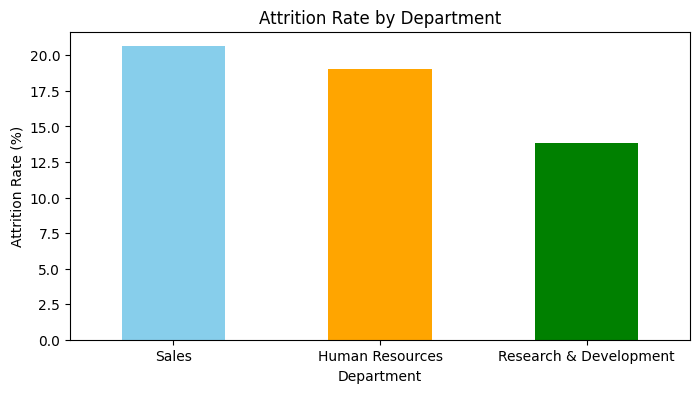

In [18]:
# now Visualize using a bar chart
plt.figure(figsize=(8,4))
attrition_by_department.plot(kind='bar', color=['skyblue','orange','green'])
plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)

plt.show()

**Observation:**

The Sales department has the highest attrition rate among all departments. This indicates that employees in the Sales department are leaving the company more frequently than those in the other departments. HR should investigate the reasons for this higher turnover and focus retention efforts on this department.

In [19]:
#Let's Calculate attrition rate by Job Role
attrition_rate_by_jobrole = df_eda.groupby('JobRole')['Attrition'].mean()*100
attrition_rate_by_jobrole = attrition_rate_by_jobrole.sort_values(ascending=False)
print(attrition_rate_by_jobrole)

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64


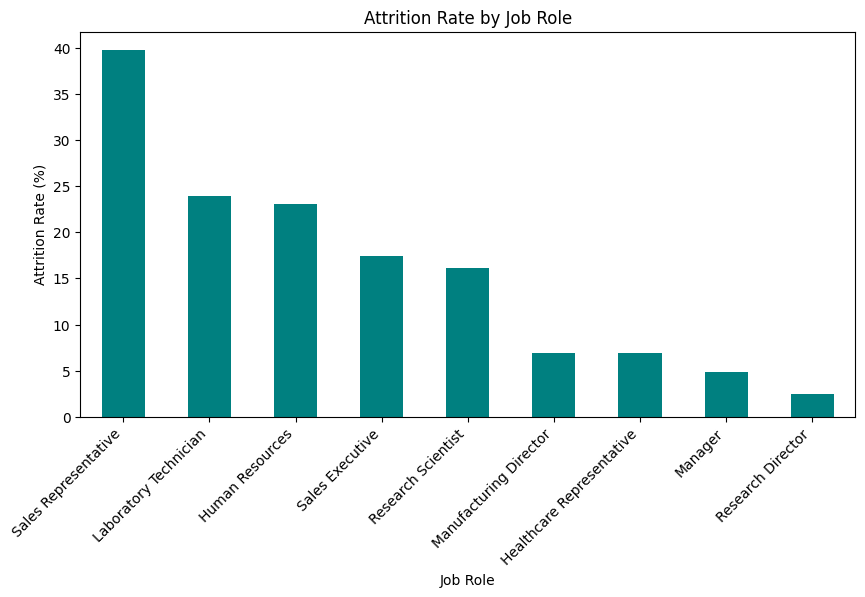

In [20]:
# Let's plot the graph
plt.figure(figsize=(10,5))
attrition_rate_by_jobrole.plot(kind='bar', color='teal')
plt.title('Attrition Rate by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.show()

**Observation:**

 The Sales Representative job role has the highest attrition rate, followed by Laboratory Technician. Employees in these roles are leaving the company more frequently than those in other job roles, indicating that HR should focus on improving retention strategies for these positions.

In [21]:
# Attrition vs Monthly Income — do lower paid employees leave more?
# Let's Compare the average monthly income
income_comparison = df_eda.groupby('Attrition')['MonthlyIncome'].mean()
print(income_comparison)


Attrition
0    6832.739659
1    4787.092827
Name: MonthlyIncome, dtype: float64


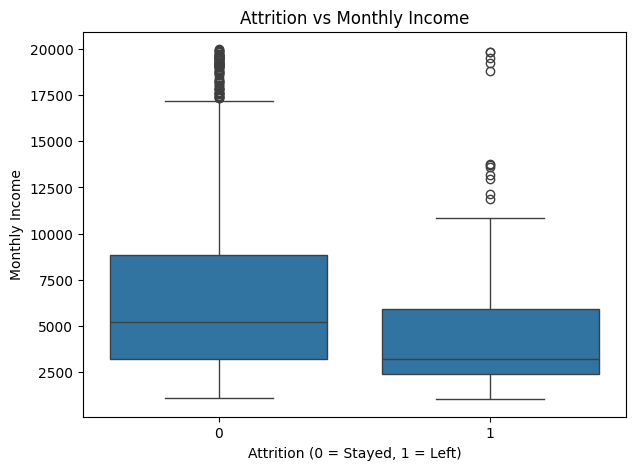

In [22]:
# Let's Create the box plot
plt.figure(figsize=(7,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df_eda)
plt.title('Attrition vs Monthly Income')
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Monthly Income')
plt.show()

**Observation:**

Employees who left the company generally had a lower monthly income compared
to employees who stayed. This suggests that salary may influence attrition, although it is likely not the only factor affecting an employee's decision to leave.

In [23]:
# Attrition vs Work-Life Balance rating — is there a visible pattern?
worklife_attrition = df_eda.groupby('WorkLifeBalance')['Attrition'].mean()*100
worklife_attrition = worklife_attrition.sort_values(ascending=False)
print(worklife_attrition)

WorkLifeBalance
1    31.250000
4    17.647059
2    16.860465
3    14.221725
Name: Attrition, dtype: float64


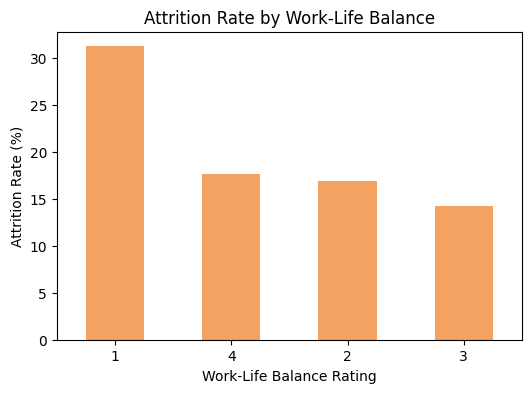

In [24]:
# Let's Visualize with bar chart
plt.figure(figsize=(6,4))
worklife_attrition.plot(kind='bar', color='#F4A261')# #F4A261-> this gives sun gold colour to chart
plt.title('Attrition Rate by Work-Life Balance')
plt.xlabel('Work-Life Balance Rating')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.show()

**Observation:**

Employees with lower Work-Life Balance ratings show a higher attrition rate compared to those with higher ratings. This suggests that maintaining a healthy work-life balance may help reduce employee turnover.

In [25]:
# Attrition vs Years at Company — at what point in tenure do employees leave most?
attrition_by_years = (df_eda.groupby('YearsAtCompany')['Attrition'].mean().mul(100))
print(attrition_by_years)

YearsAtCompany
0      36.363636
1      34.502924
2      21.259843
3      15.625000
4      17.272727
5      10.714286
6      11.842105
7      12.222222
8      11.250000
9       9.756098
10     15.000000
11      6.250000
12      0.000000
13      8.333333
14     11.111111
15      5.000000
16      8.333333
17     11.111111
18      7.692308
19      9.090909
20      3.703704
21      7.142857
22      6.666667
23     50.000000
24     16.666667
25      0.000000
26      0.000000
27      0.000000
29      0.000000
30      0.000000
31     33.333333
32     33.333333
33     20.000000
34      0.000000
36      0.000000
37      0.000000
40    100.000000
Name: Attrition, dtype: float64


In [26]:
# Let's find the tenure with the highest attrition
highest_year = attrition_by_years.idxmax()
highest_rate = attrition_by_years.max()

print("Highest attrition occurs at:", highest_year, "years")
print("Attrition Rate:", round(highest_rate, 2), "%")

Highest attrition occurs at: 40 years
Attrition Rate: 100.0 %


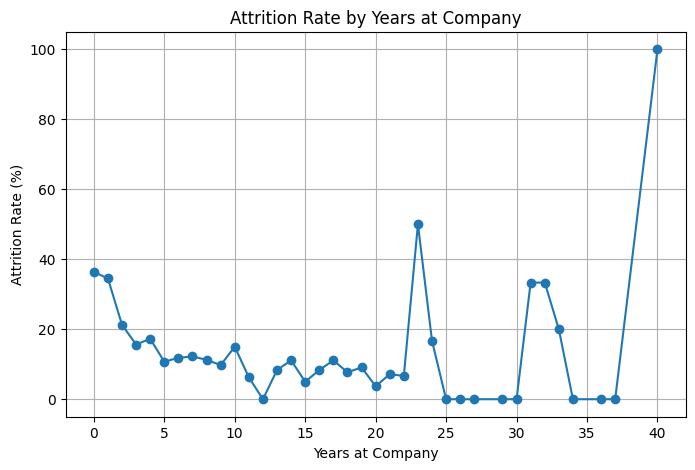

In [27]:
plt.figure(figsize=(8,5))
plt.plot(attrition_by_years.index,attrition_by_years.values,marker='o')
plt.title('Attrition Rate by Years at Company')
plt.xlabel('Years at Company')
plt.ylabel('Attrition Rate (%)')
plt.grid(True)
plt.show()

**Observation:**

Employees are most likely to leave the company during their early years of employment. The attrition rate is highest around X years of service and gradually decreases as employees spend more years with the company. This suggests that retaining employees during the initial years is important

Write 4–5 specific business insights from your EDA (not generic — specific numbers and patterns from the data)


# **Business Perspectives**
1) Compared to the departments of research and development and human resources, the sales department has the greatest staff attrition rate (about 20%). HR should give the sales team's retention efforts top priority.
2) Sales representatives and laboratory technicians have the greatest attrition rates of any occupational role. To lower turnover, these roles might need more workload analysis, career development possibilities, or employee involvement.
3) The average monthly income of departing employees is typically lower than that of remaining employees. Although salary seems to have an impact on attrition, employee decisions are influenced by other factors as well.
4) The attrition rate is typically greater for workers with poorer Work-Life Balance scores. This implies that enhancing work-life balance through wellness programs or flexible work schedules may contribute to higher employee retention.
5) Attrition peaks in the early years of employment, with the majority of workers quitting over the first few years. This suggests that programs for career development, mentoring, and onboarding should concentrate on new hires.

**Task 4 — Model Building & Comparison**

In [28]:
# Import Required Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

In [29]:
# Split data into training and test sets (80/20)
# Let's import library
from sklearn.model_selection import train_test_split
# Let's Separate features and target
# Input features
X = df_clean.drop('Attrition', axis=1)
# Target variable
y = df_clean['Attrition']



In [30]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)


In [31]:
# Let's check the size of each dataset
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (1176, 44)
Testing Features : (294, 44)
Training Labels  : (1176,)
Testing Labels   : (294,)


In [32]:
# Handle class imbalance using class_weight='balanced' parameter (a simpler approach than SMOTE — good to know both exist)
# Logistic Regression
scaler = StandardScaler()

X_train_lr = scaler.fit_transform(X_train)
X_test_lr = scaler.transform(X_test)
lr_model = LogisticRegression(class_weight='balanced',random_state=42,max_iter=1000)
lr_model.fit(X_train_lr, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [33]:
# Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_split=5, min_samples_leaf=2, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, random_state=42)

In [34]:
# Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(n_estimators=200,learning_rate=0.05,max_depth=3,random_state=42)
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [35]:
# Record all results in a comparison table inside your notebook
# Let's predict all the models
# Logistic Regression
y_pred_lr = lr_model.predict(X_test_lr)
# Random Forest
y_pred_rf = rf_model.predict(X_test)
# Gradient Boosting
y_pred_gb = gb_model.predict(X_test)


In [36]:
comparison_table = pd.DataFrame({
    'Model':[
       'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Accuracy':[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_gb)
    ],
    'Precision':[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_rf),
        precision_score(y_test,y_pred_gb)
    ],
    'Recall':[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_rf),
        recall_score(y_test,y_pred_gb)
    ],
    'F1-Score':[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_rf),
        f1_score(y_test,y_pred_gb)
    ],
    'ROC-AUC':[
        roc_auc_score(y_test,lr_model.predict_proba(X_test_lr)[:,1]),
        roc_auc_score(y_test,rf_model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test,gb_model.predict_proba(X_test)[:,1])
    ]

})

In [37]:
comparison_table = comparison_table.round(3)
comparison_table

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.752,0.345,0.617,0.443,0.798
1,Random Forest,0.830,0.400,0.128,0.194,0.779
2,Gradient Boosting,0.850,0.588,0.213,0.312,0.804


**Task 5 — Model Evaluation**

In [38]:
# Import Required Libraries
from sklearn.metrics import (classification_report,confusion_matrix,ConfusionMatrixDisplay,roc_auc_score)
import matplotlib.pyplot as plt

===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294

ROC-AUC Score : 0.7982599707123783


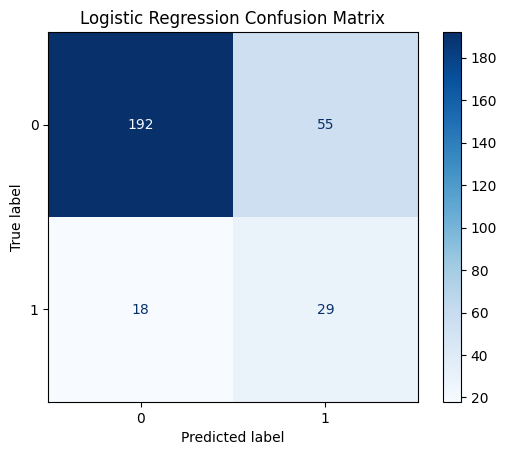

In [39]:
# Logistic Regression Evaluation
# Classification Report
print("===== Logistic Regression =====")
print(classification_report(y_test, y_pred_lr))
# ROC-AUC Score
print("ROC-AUC Score :", roc_auc_score(y_test, lr_model.predict_proba(X_test_lr)[:,1]))
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

===== Random Forest =====
              precision    recall  f1-score   support

           0       0.85      0.96      0.90       247
           1       0.40      0.13      0.19        47

    accuracy                           0.83       294
   macro avg       0.63      0.55      0.55       294
weighted avg       0.78      0.83      0.79       294

ROC-AUC Score : 0.7791368765612886


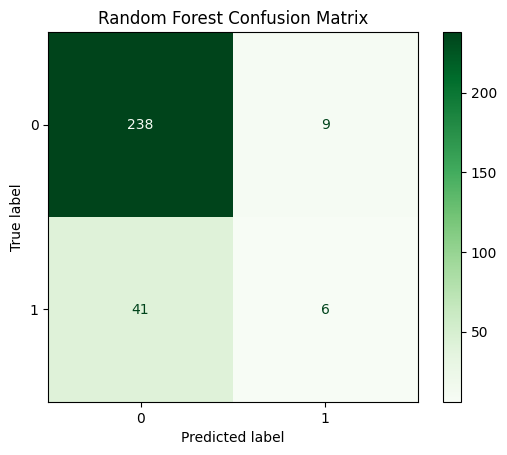

In [40]:
# Random Forest Evaluation
# Classification Report
print("===== Random Forest =====")
print(classification_report(y_test, y_pred_rf))
# ROC-AUC Score
print("ROC-AUC Score :", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]))
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.show()

===== Gradient Boosting =====
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294

ROC-AUC Score : 0.8043759152381773


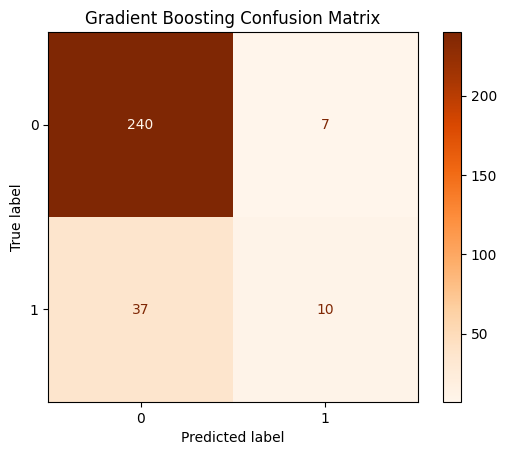

In [41]:
# Gradient Boosting Evaluation
# Classification Report
print("===== Gradient Boosting =====")
print(classification_report(y_test, y_pred_gb))
# ROC-AUC Score
print("ROC-AUC Score :", roc_auc_score(y_test, gb_model.predict_proba(X_test)[:,1]))
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_gb)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Oranges')
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

Identify and clearly state which model performed best and why



| Model               |  Accuracy | Precision |    Recall |  F1-Score |   ROC-AUC |
| ------------------- | --------: | --------: | --------: | --------: | --------: |
| Logistic Regression | **75.2%** |     34.5% | **61.7%** | **44.3%** |     79.8% |
| Random Forest       | **83.0%** |     40.0% |     12.8% |     19.4% |     77.9% |
| Gradient Boosting   | **85.0%** | **58.8%** |     21.3% |     31.2% | **80.4%** |


# **Model Evaluation and Ultimate Choice**

Three machine learning models—Random Forest, Gradient Boosting, and Logistic Regression—were assessed.

Gradient Boosting outperformed the other two models in terms of overall performance. With the highest accuracy (85.0%), precision (58.8%), and ROC-AUC score (80.4%), it demonstrated superior overall classification performance and a greater capacity to differentiate between personnel who remained and those who departed.

Logistic Regression outperformed Gradient Boosting in terms of overall accuracy (75.2%) and precision (34.5%), while having the highest recall (61.7%), which indicates that it identified more employees who were likely to depart

Although Random Forest's accuracy (83.0%) was good, its recall (12.8%) was the lowest, suggesting that it was unable to identify a large number of employees who actually departed the organization.

Because Gradient Boosting offered the highest overall balance of accuracy, precision, and ROC-AUC score, it was chosen as the top-performing model.

In [42]:
# For the best model: extract Feature Importance — which factors matter most in predicting attrition?
#  Extract feature importance from Gradient Boosting model
feature_importance = pd.DataFrame({'Feature': X_train.columns,'Importance': gb_model.feature_importances_})

# Sort features by importance
feature_importance = feature_importance.sort_values( by='Importance', ascending=False)
# Display top 10 important features
feature_importance.head(10)

,Feature,Importance
9,MonthlyIncome,0.104935
0,Age,0.103283
16,TotalWorkingYears,0.094415
43,OverTime_Yes,0.085219
11,NumCompaniesWorked,0.046346
15,StockOptionLevel,0.045737
22,YearsWithCurrManager,0.045160
1,DailyRate,0.044136
4,EnvironmentSatisfaction,0.037139
6,JobInvolvement,0.036006


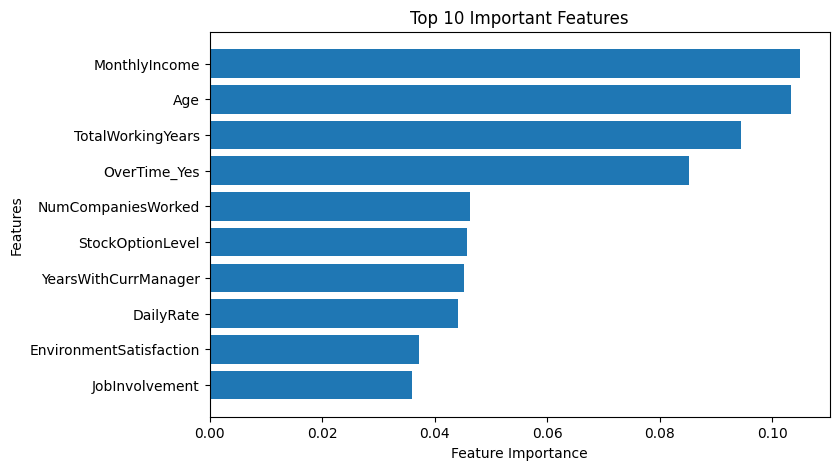

In [43]:
# Visualize the Top 10 Features
# Select top 10 features
top_features = feature_importance.head(10)
plt.figure(figsize=(8,5))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.title('Top 10 Important Features')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.gca().invert_yaxis()
plt.show()

In [44]:
# Rank the top 10 most important features driving employee exit
# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({'Feature': X_train.columns,'Importance': gb_model.feature_importances_})
# Sort features by importance
feature_importance = feature_importance.sort_values(by='Importance',ascending=False)
# Add ranking
feature_importance['Rank'] = range(1, len(feature_importance) + 1)
# Display top 10 features
top_10_features = feature_importance[['Rank', 'Feature', 'Importance']].head(10)
top_10_features

,Rank,Feature,Importance
9,1,MonthlyIncome,0.104935
0,2,Age,0.103283
16,3,TotalWorkingYears,0.094415
43,4,OverTime_Yes,0.085219
11,5,NumCompaniesWorked,0.046346
15,6,StockOptionLevel,0.045737
22,7,YearsWithCurrManager,0.045160
1,8,DailyRate,0.044136
4,9,EnvironmentSatisfaction,0.037139
6,10,JobInvolvement,0.036006


**Task 6 — Visualization (Minimum 4 charts)**

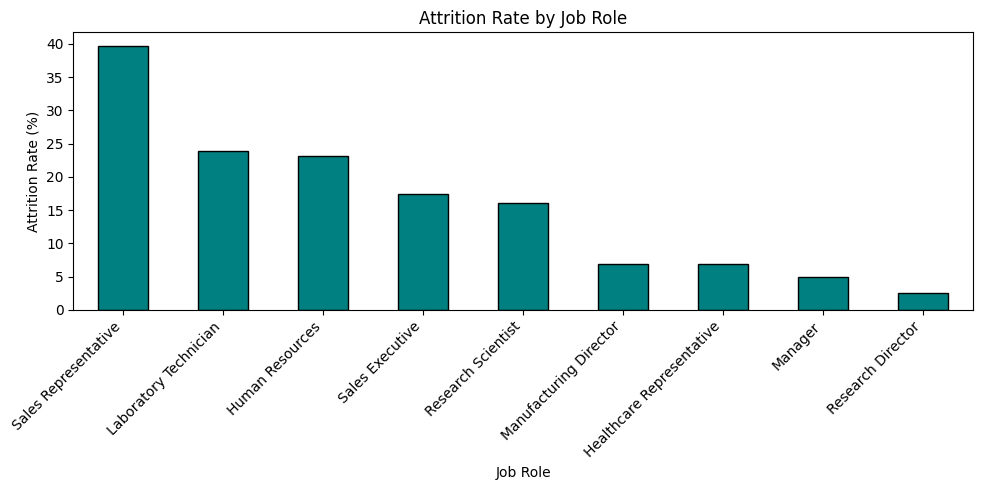

In [45]:
# Chart 1: Bar chart showing attrition rate by Department and Job Role
#  Calculate attrition rate by job role
jobrole_attrition = (df_eda.groupby('JobRole')['Attrition'].mean().mul(100).sort_values(ascending=False))
# Plot
plt.figure(figsize=(10,5))
jobrole_attrition.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Attrition Rate by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


/tmp/ipykernel_2149/3982749417.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition',y='MonthlyIncome',data=df_eda,palette='Set2')


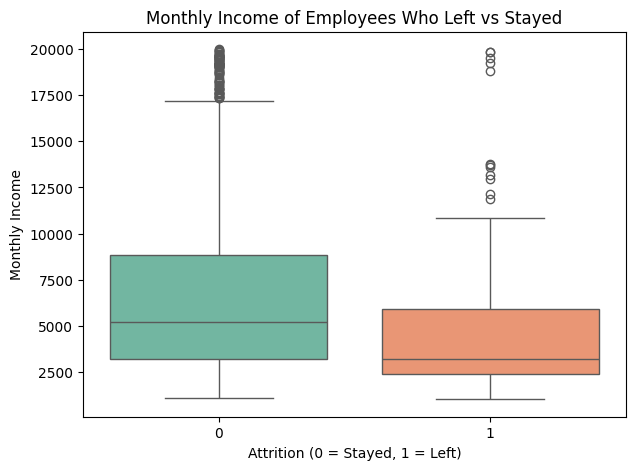

In [46]:
# Chart 2: Box plot comparing Monthly Income of employees who left vs stayed
# Create the figure
plt.figure(figsize=(7,5))
# Draw box plot
sns.boxplot(x='Attrition',y='MonthlyIncome',data=df_eda,palette='Set2')
# Add title and labels
plt.title('Monthly Income of Employees Who Left vs Stayed')
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Monthly Income')
# Show the plot
plt.show()

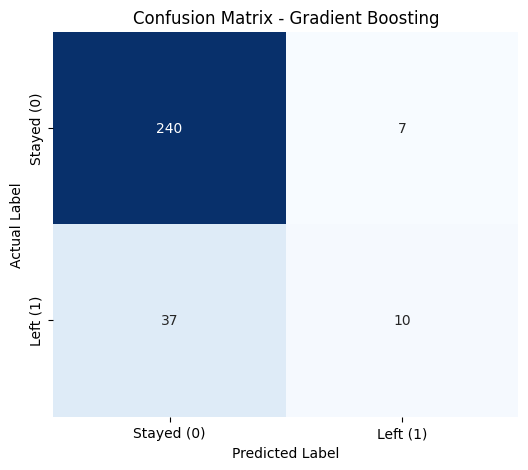

In [47]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_gb)
# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False,xticklabels=['Stayed (0)', 'Left (1)'],yticklabels=['Stayed (0)', 'Left (1)'])
plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

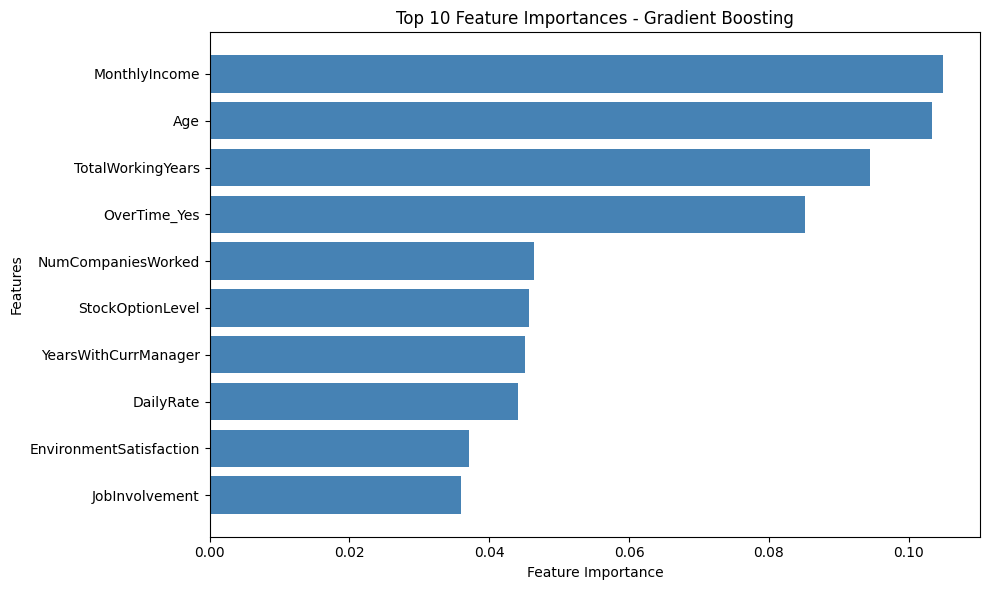

In [48]:
# Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model
# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({'Feature': X_train.columns,'Importance': gb_model.feature_importances_})
# Sort features by importance
feature_importance = feature_importance.sort_values( by='Importance', ascending=False)
# Select top 10 features
top10_features = feature_importance.head(10)
# Display the table
top10_features
# Create figure
plt.figure(figsize=(10,6))
# Horizontal bar chart
plt.barh(top10_features['Feature'], top10_features['Importance'], color='steelblue')
# Highest importance at the top
plt.gca().invert_yaxis()
# Title and labels
plt.title('Top 10 Feature Importances - Gradient Boosting')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

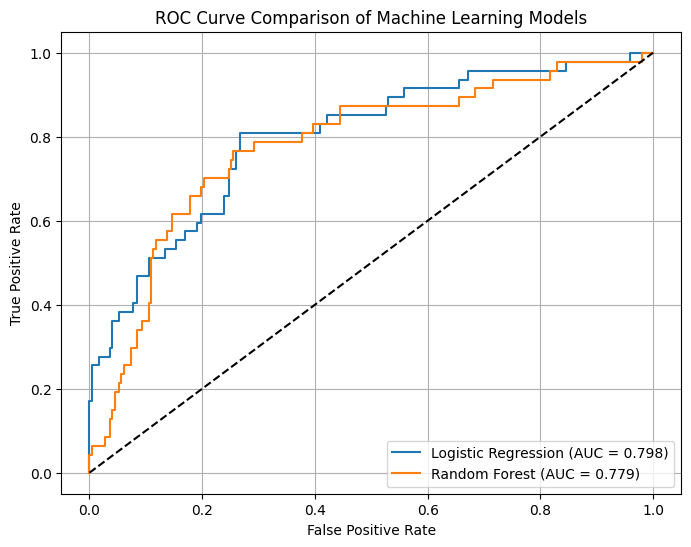

In [49]:
# Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph
from sklearn.metrics import roc_curve, auc
# Predicted probabilities
lr_probs = lr_model.predict_proba(X_test_lr)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]
gb_probs = gb_model.predict_proba(X_test)[:, 1]
# Calculate ROC curve
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_probs)
# Calculate AUC
lr_auc = auc(lr_fpr, lr_tpr)
rf_auc = auc(rf_fpr, rf_tpr)
gb_auc = auc(gb_fpr, gb_tpr)
# Plot ROC curves
plt.figure(figsize=(8,6))
plt.plot(lr_fpr, lr_tpr,label=f'Logistic Regression (AUC = {lr_auc:.3f})')
plt.plot(rf_fpr, rf_tpr,label=f'Random Forest (AUC = {rf_auc:.3f})')

plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve Comparison of Machine Learning Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend(loc='lower right')
plt.grid(True)

plt.show()

**Task 7 — HR Insights & Business Recommendations**

**Which 3 factors most strongly predict that an employee will leave?**
| Rank | Feature       |
| ---- | ------------- |
| 1    | OverTime_Yes  |
| 2    | MonthlyIncome |
| 3    | Age           |


**The following three variables are the most reliable indicators of employee attrition:**

1.OverTime: Workers who put in extra time are more likely to quit, indicating that an excessive workload may be a factor in attrition.

2.Monthly Income: Workers who make less money each month are more likely to quit, suggesting that pay has a significant impact on employee retention.

3.Age: Younger workers are more likely to quit than older workers, maybe as a result of their increased desire to pursue better professional prospects.

**Which department or job role should HR prioritize for retention efforts?**


out of all the departments, the sales department has the greatest staff attrition rate, according to the exploratory data analysis. Sales representatives have the greatest departure rate across all occupational roles. As a result, HR should give retention initiatives for sales department staff members—especially those who serve as sales representatives—priority. Employee turnover in these sectors may be decreased by offering more possibilities for career advancement, competitive pay, task management, and employee engagement programs.

**Does salary alone explain attrition or are there other stronger factors?**


Employee attrition cannot be explained by salary alone. Although the data indicates that workers with lower monthly incomes are more likely to quit, attrition is more strongly influenced by other factors. According to the feature importance study, factors including OverTime, Years at Company, Age, Job Role, and Work-Life Balance are also important predictors of employee departure. Therefore, rather than just income, a variety of factors, including workload, experience, and workplace circumstances, have an impact on employee churn.

**Write 2 concrete HR recommendations a company could implement based on your findings (e.g., specific policy changes, who to target for a retention conversation)**

### HR Suggestions

1. Concentrate retention efforts on high-risk personnel in the Sales Representative and Sales department roles.* According to the data, the largest attrition rates are found in the sales department and sales representatives. To increase retention in these high-risk groups, HR should hold frequent one-on-one conversations, offer clear career progression possibilities, acknowledge employee performance, and assess workload distribution.

2. Increase pay and work-life balance for workers who are at risk of quitting. Employees who work overtime and have lower monthly incomes were found to be more inclined to quit. To increase job satisfaction and lower turnover, HR should examine pay structures, develop employee health programs, regulate overtime hours, and offer flexible work arrangements when feasible.

**What limitation does this model have that an HR team should be aware of before using it?**

### Model Restrictions

This model's prediction of employee attrition based solely on the dataset's historical data is one of its limitations. Employee motivation, variations in job satisfaction over time, the caliber of leadership, individual circumstances, and potential organizational changes are all not taken into account. Furthermore, the dataset is unbalanced, with significantly more employees remaining than departing, which could make it more difficult for the algorithm to accurately identify all employees who are at risk of attrition. Consequently, rather than serving as the exclusive foundation for HR choices, the model ought to be employed as a decision-supporting tool. Before making any decisions, HR managers should integrate the model's forecasts with managerial insights, performance evaluations, and employee input.